# Data Ingesting

In [2]:
!pip install langchain-community

In [3]:
from langchain_community.document_loaders import UnstructuredPDFLoader
from langchain_community.document_loaders import OnlinePDFLoader

In [5]:
# path = "./laws-of-cricket-2017-code-3rd-edition-2022_1.pdf"
# path = "./Game_of_Thrones.pdf"
path = "./Mens_Standard_ODI_Playing_Conditions-Effective_December_2023.pdf"

if path:
    loader = UnstructuredPDFLoader(file_path = path)
    data = loader.load()
else:
    print("Upload a pdf file")

In [6]:
data

[Document(metadata={'source': './Mens_Standard_ODI_Playing_Conditions-Effective_December_2023.pdf'}, page_content="ICC Men’s Standard ODI Playing Conditions\n\nEffective December 2023\n\nCONTENTS\n\n1\n\nTHE PLAYERS ...................................................................................................................................................... 1\n\n2\n\nTHE UMPIRES ...................................................................................................................................................... 3\n\n3\n\nTHE SCORERS .................................................................................................................................................... 7\n\n4\n\nTHE BALL ............................................................................................................................................................. 7\n\n5\n\nTHE BAT ..............................................................................................

In [7]:
data[0].page_content[:500]

'ICC Men’s Standard ODI Playing Conditions\n\nEffective December 2023\n\nCONTENTS\n\n1\n\nTHE PLAYERS ...................................................................................................................................................... 1\n\n2\n\nTHE UMPIRES ...................................................................................................................................................... 3\n\n3\n\nTHE SCORERS .....................................................................'

# Vector Embeddings

In [8]:
!pip install --q langchain-text-splitters

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
#Split and Chunk
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1200, chunk_overlap = 100, add_start_index = True)
chunks = text_splitter.split_documents(data)

In [10]:
chunks

[Document(metadata={'source': './Mens_Standard_ODI_Playing_Conditions-Effective_December_2023.pdf', 'start_index': 0}, page_content='ICC Men’s Standard ODI Playing Conditions\n\nEffective December 2023\n\nCONTENTS\n\n1\n\nTHE PLAYERS ...................................................................................................................................................... 1\n\n2\n\nTHE UMPIRES ...................................................................................................................................................... 3\n\n3\n\nTHE SCORERS .................................................................................................................................................... 7\n\n4\n\nTHE BALL ............................................................................................................................................................. 7\n\n5\n\nTHE BAT ............................................................................

In [11]:
print("Number of chunks created:", len(chunks))

Number of chunks created: 254


In [12]:
!pip install -U langchain-ollama

In [13]:
!ollama pull all-minilm

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest 
pulling 797b70c4edf8: 100% ▕██████████████████▏  45 MB                         
pulling c71d239df917: 100% ▕██████████████████▏  11 KB                         
pulling 85011998c600: 100% ▕██████████████████▏   16 B                         
pulling 548455b72658: 100% ▕██████████████████▏  407 B                         
verifying sha256 digest 
writing manifest 
success 


In [14]:
!ollama pull mistral

pulling manifest ⠋ pulling manifest ⠙ pulling manifest 
pulling f5074b1221da: 100% ▕██████████████████▏ 4.4 GB                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling 1ff5b64b61b9: 100% ▕██████████████████▏  799 B                         
pulling ed11eda7790d: 100% ▕██████████████████▏   30 B                         
pulling 1064e17101bd: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest 
writing manifest 
success 


In [15]:
!ollama pull phi3

pulling manifest ⠋ pulling manifest ⠙ pulling manifest 
pulling 633fc5be925f: 100% ▕██████████████████▏ 2.2 GB                         
pulling fa8235e5b48f: 100% ▕██████████████████▏ 1.1 KB                         
pulling 542b217f179c: 100% ▕██████████████████▏  148 B                         
pulling 8dde1baf1db0: 100% ▕██████████████████▏   78 B                         
pulling 23291dc44752: 100% ▕██████████████████▏  483 B                         
verifying sha256 digest 
writing manifest 
success 


In [16]:
!ollama list

NAME                 ID              SIZE      MODIFIED               
phi3:latest          4f2222927938    2.2 GB    Less than a second ago    
mistral:latest       6577803aa9a0    4.4 GB    1 second ago              
all-minilm:latest    1b226e2802db    45 MB     3 seconds ago             
llama3.2:latest      a80c4f17acd5    2.0 GB    2 weeks ago               
gemma3:4b            a2af6cc3eb7f    3.3 GB    2 weeks ago               


In [17]:
from langchain_community.embeddings import OllamaEmbeddings
local_embeddings = OllamaEmbeddings(model = "all-minilm", show_progress = True)

/var/folders/9s/xzlzbh1n5n7437vx84k174mw0000gn/T/ipykernel_30084/743769064.py:2: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  local_embeddings = OllamaEmbeddings(model = "all-minilm", show_progress = True)


In [18]:
!pip install langchain-chroma

In [19]:
import os
import shutil
from langchain_chroma import Chroma

# Setting up a proper readable and writable folder for db
persist_dir = os.path.expanduser("~/chroma_db")

# Deleting old database if it exists
if os.path.exists(persist_dir):
    shutil.rmtree(persist_dir, ignore_errors=True)

# Recreating the deleted folder
os.makedirs(persist_dir, exist_ok=True)

#Creating fresh Chroma vector db in order to prevent appending or readding data
vector_db = Chroma.from_documents(
    documents=chunks,          # your PDF chunks
    embedding=local_embeddings, # your embedding object
    persist_directory=persist_dir
)

# Vector DB Location
print("Fresh Chroma DB created at:", persist_dir)


OllamaEmbeddings: 100%|███████████████████████| 254/254 [00:06<00:00, 36.96it/s]

Fresh Chroma DB created at: /Users/kalamuddin/chroma_db


# Retrieval

In [20]:
def rag_response(llm, question, k = 3):
    retriever = vector_db.as_retriever(search_type = "similarity", search_kwargs = {"k": k})
    retrieved_docs = retriever.invoke(question)
    context = ' '.join([doc.page_content for doc in retrieved_docs])
    template = f"""
You are a strict assistant answering VERY briefly to the question ONLY based on the context, if possible mention the law code at the end of the answer.
NOTE: Do NOT invent or infer rules that are not explicitly stated in the CONTEXT:

CONTEXT:
{context}

QUESTION:
{question}"""
    
    return context, llm.invoke(template)

# Response

In [21]:
# Questions and expected answers

questions = [
    "What is a no-ball?",
    "What is a boundary six in cricket?",
    "What is the powerplay in ODI cricket?",
    "What does LBW stand for?",
    
    "How many players constitute the playing eleven in an ODI match for each side according to ICC standard ODI playing conditions?",
    "What is the maximum number of substitute fielders a team may nominate in addition to their playing eleven before the toss?",
    "Can a player from the starting eleven be replaced after the toss without consent of the opposing captain?",
    
    "If a substitute fielder is used, under what condition(s) must the substitute have been nominated before the match?",
    "According to standard ODI playing conditions, which official(s) must verify the nominated playing eleven and substitutes immediately prior to the toss?",
    "Is the use of the standard Laws of Cricket retained in ODI matches under ICC playing conditions, except where modified by the ODI Playing Conditions document?",
    
    "Under the standard ODI playing conditions, what happens if a player is absent from the field for longer than 8 minutes during a session of play?",
    "According to ODI playing conditions, who has the authority to allow a suspended player or support personnel to act as a substitute fielder during a match?",
    "Does the substitute-fewer rule allow any player not named on the original nomination list to field as a substitute under normal circumstances?",  
    "What happens to a substitute fielder’s eligibility if he or she has been suspended from participation in the match from the toss onward?"
]

gold_answers = [
    #1
    "A no-ball is an illegal delivery, usually for overstepping or dangerous bowling, and gives one extra run.",
    #2
    "A boundary six is when the batter hits the ball over the boundary rope without it touching the ground, giving six runs.",
    #3
    "The powerplay is a fielding restriction period at the start of an ODI innings.",
    #4
    "LBW stands for Leg Before Wicket.",
    #5
    "Each side’s playing eleven must consist of eleven players. (Clause 1)",
    #6
    "In addition to the playing eleven, a team may nominate up to four substitute fielders. (Clause 1.2.1)",
    #7
    "No — a member of the playing eleven may not be replaced after nomination and before the start of play without the consent of the opposing captain. (Clause 1.2.1)",
    #8
    "Any substitute fielder must have been nominated on the team sheet before the toss to be eligible to act as substitute during the match. (Clause 1.2.1 / 1.2.3)",
    #9
    "The ICC Match Referee or their nominee must check with both captains immediately prior to the toss that the players nominated are correct. (Clause 1.2.2)",
    #10
    "Yes — except as varied by the ODI Playing Conditions, the general Laws of Cricket apply to ODI matches under ICC playing conditions. (Preamble / application clause)",
    #11
    "If a player is absent from the field for more than 8 minutes without acceptable reason, then upon return they shall be ineligible to bowl in that innings, and batting only after the side has lost five wickets or the innings has been in progress for the same time as absence. (Modified Law 2 clause, under absence rule)",
    #12
    "Only those nominated as substitute fielders before the toss are entitled to act as substitute fielders, unless exceptional circumstances with consent of ICC Match Referee. (Clause 1.2.3)",
    #13
    "No — only players nominated on the original team-sheet (playing eleven + substitute fielders) are permitted to act as substitute fielders under normal circumstances. (Clause 1.2.1 / 1.2.3)",
    #14
    "If a substitute or support personnel has been suspended from participation from toss onward, they may not act as a substitute fielder for the remainder of the match. (Clause 1.2.6)"
]


In [22]:
from langchain_ollama.llms import OllamaLLM
import pandas as pd

llama = OllamaLLM(model = "llama3.2")
phi = OllamaLLM(model = "phi3")
mistral = OllamaLLM(model = "mistral")

results = []

for q in questions:
    context_llama, response_llama = rag_response(llama, q)
    context_phi, response_phi = rag_response(phi, q)
    context_mistral, response_mistral = rag_response(mistral, q)

    results.append({
        "Question": q,
        "Context": context_llama,
        "Llama3.2 Answer": response_llama,
        # "Phi3 Context": context_phi,
        "Phi3 Answer": response_phi,
        # "Mistral Context": context_mistral,
        "Mistral Answer": response_mistral
    })

df_results = pd.DataFrame(results)
df_results

OllamaEmbeddings: 100%|███████████████████████████| 1/1 [00:00<00:00,  1.88it/s]


,Question,Context,Llama3.2 Answer,Phi3 Answer,Mistral Answer
0,What is a no-ball?,21.16 Runs resulting from a No ball – how scor...,A No ball is called when the bowler breaks the...,"A No-ball, also known as an illegal delivery b...","A No-ball is an illegal delivery in cricket, ..."
1,What is a boundary six in cricket?,4.4\n\nThe bowler’s end is the end from which ...,A boundary six in cricket is scored when the b...,A run scored when the ball first touches the g...,A boundary six in cricket is a hit that allow...
2,What is the powerplay in ODI cricket?,"restriction area. In an innings of 50 overs, t...",The Powerplay in ODI cricket consists of three...,The Powerplay consists of a specified number o...,The Powerplay in ODI cricket refers to specif...
3,What does LBW stand for?,"3.9.4\n\nFor illustration, following an LBW ap...",LBW stands for Leg Before Wicket.\n\nLaw Code:...,"Leg before wicket; ICC Code of Conduct, Laws a...",LBW stands for Leg Before Wicket.
4,How many players constitute the playing eleven...,Thank the officials and your opposition at the...,"Eleven players, one of whom shall be captain. ...",Each team has a playing eleven of eleven playe...,Eleven players for each side constitute the p...
5,What is the maximum number of substitute field...,Thank the officials and your opposition at the...,A team may nominate a maximum of 4 substitute ...,A cricket match allows for up to four addition...,The maximum number of substitute fielders a t...
6,Can a player from the starting eleven be repla...,Thank the officials and your opposition at the...,"No, according to Clause 1.2.1, no player (memb...","No, such replacement is not allowed unless the...","No, a player from the starting eleven cannot ..."
7,"If a substitute fielder is used, under what co...",69\n\nthe wicket-keeper but also nominated pla...,The substitute fielder must have been nominate...,A substitute fielder may be used only if they ...,The substitute fielder must be nominated by e...
8,"According to standard ODI playing conditions, ...",Thank the officials and your opposition at the...,The ICC Match Referee.\n\n(IQ Code 42.2.2.3),The ICC Match Referee verifies the nomination ...,The ICC Match Referee must verify the nominat...
9,Is the use of the standard Laws of Cricket ret...,42.3 Captain refusing to remove a player from ...,"Yes.\n\nICC Playing Conditions (App A), Defini...","Yes, the context indicates that Law 1 (The bal...",Yes [63]. The use of the standard Laws of Cri...


In [23]:
print("Question: What is a no-ball?")
print("\n")
print("LLama3.2 Answer:")
print(df_results.iloc[0, 2])
print("\n\n")
print("Phi3 Answer:")
print(df_results.iloc[0, 3])
print("\n\n")
print("Mistral Answer:")
print(df_results.iloc[0, 4])
print("\n\n")
# print(df_results.iloc[0, 1])

Question: What is a no-ball?


LLama3.2 Answer:
A No ball is called when the bowler breaks the wicket at any time after the ball comes into play and before completion of the stride after the delivery stride, or if the ball bounces more than once, rolls along the ground, or pitches off the pitch. Law Code: 20.



Phi3 Answer:
A No-ball, also known as an illegal delivery by the bowling side that denies the batting team certain rights. A No-ball results in one penalty run awarded to the batting side and any runs completed thereafter will be added except for wides or no-rejections unless otherwise mentioned; if a dismissal occurs during a No-ball, it's disregarded with an extra run given instead (clause 21.5). The ball must not bounce more than once before reaching the popping crease and cannot pitch off the edge of the pitch without touching bat or person first; these are considered no-ball deliveries (clauses 21.7, 21.8).

Law Code: Law 21.5



Mistral Answer:
 A No-ball is an illegal de

In [24]:
!pip install sentence-transformers

In [25]:
from sentence_transformers import SentenceTransformer, util

eval_model = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_similarity(answer, context):
    emb_a = eval_model.encode(answer, convert_to_tensor=True)
    emb_c = eval_model.encode(context, convert_to_tensor=True)
    return float(util.pytorch_cos_sim(emb_a, emb_c))

In [26]:
eval_rows = []

for _, row in df_results.iterrows():

    eval_rows.append({
        "Question": row["Question"],
        "Llama Similarity": semantic_similarity(str(row["Llama3.2 Answer"]), row["Context"]),
        "Phi Similarity": semantic_similarity(str(row["Phi3 Answer"]), row["Context"]),
        "Mistral Similarity": semantic_similarity(str(row["Mistral Answer"]), row["Context"]),
    })

df_eval = pd.DataFrame(eval_rows)
df_eval


,Question,Llama Similarity,Phi Similarity,Mistral Similarity
0,What is a no-ball?,0.730091,0.800472,0.707447
1,What is a boundary six in cricket?,0.547975,0.450104,0.533895
2,What is the powerplay in ODI cricket?,0.709125,0.755852,0.760073
3,What does LBW stand for?,0.542776,0.589315,0.498091
4,How many players constitute the playing eleven...,0.504858,0.599114,0.605314
5,What is the maximum number of substitute field...,0.752985,0.786080,0.774972
6,Can a player from the starting eleven be repla...,0.744849,0.635206,0.701258
7,"If a substitute fielder is used, under what co...",0.716870,0.716950,0.670748
8,"According to standard ODI playing conditions, ...",0.493663,0.693061,0.737810
9,Is the use of the standard Laws of Cricket ret...,0.462207,0.517304,0.587475


In [27]:
#Function to find similarity
def semantic_similarity(a, b):
    emb_a = eval_model.encode(str(a), convert_to_tensor=True)
    emb_b = eval_model.encode(str(b), convert_to_tensor=True)
    return float(util.pytorch_cos_sim(emb_a, emb_b))



eval_rows = []

for i, row in df_results.iterrows():
    q = row["Question"]
    ctx = row["Context"]
    gold = gold_answers[i]

    llama_ans = str(row["Llama3.2 Answer"])
    phi_ans = str(row["Phi3 Answer"])
    mis_ans = str(row["Mistral Answer"])

    eval_rows.append({
        "Question": q,
        "Gold Answer": gold,

        # Accuracy: answer vs gold
        "Llama Accuracy": semantic_similarity(llama_ans, gold),
        "Phi Accuracy": semantic_similarity(phi_ans, gold),
        "Mistral Accuracy": semantic_similarity(mis_ans, gold),

        # Faithfulness: answer vs context
        "Llama Faithfulness": semantic_similarity(llama_ans, ctx),
        "Phi Faithfulness": semantic_similarity(phi_ans, ctx),
        "Mistral Faithfulness": semantic_similarity(mis_ans, ctx),

        # Detail: answer length (words)
        "Llama Detail": len(llama_ans.split()),
        "Phi Detail": len(phi_ans.split()),
        "Mistral Detail": len(mis_ans.split()),
    })

df_eval_full = pd.DataFrame(eval_rows)
df_eval_full.head()


,Question,Gold Answer,Llama Accuracy,Phi Accuracy,Mistral Accuracy,Llama Faithfulness,Phi Faithfulness,Mistral Faithfulness,Llama Detail,Phi Detail,Mistral Detail
0,What is a no-ball?,"A no-ball is an illegal delivery, usually for ...",0.782870,0.888924,0.882384,0.730091,0.800472,0.707447,50,104,67
1,What is a boundary six in cricket?,A boundary six is when the batter hits the bal...,0.809624,0.538370,0.865210,0.547975,0.450104,0.533895,51,24,52
2,What is the powerplay in ODI cricket?,The powerplay is a fielding restriction period...,0.798721,0.833021,0.897969,0.709125,0.755852,0.760073,27,65,47
3,What does LBW stand for?,LBW stands for Leg Before Wicket.,0.917916,0.583870,1.000000,0.542776,0.589315,0.498091,9,14,6
4,How many players constitute the playing eleven...,Each side’s playing eleven must consist of ele...,0.644462,0.701063,0.714787,0.504858,0.599114,0.605314,11,78,21


In [28]:
import numpy as np

# Aggregating the metrics per model
model_scores = {
    "Llama 3.2": {
        "Accuracy": df_eval_full["Llama Accuracy"].mean(),
        "Faithfulness": df_eval_full["Llama Faithfulness"].mean(),
        "Detail": df_eval_full["Llama Detail"].mean()
    },
    "Phi-3": {
        "Accuracy": df_eval_full["Phi Accuracy"].mean(),
        "Faithfulness": df_eval_full["Phi Faithfulness"].mean(),
        "Detail": df_eval_full["Phi Detail"].mean()
    },
    "Mistral": {
        "Accuracy": df_eval_full["Mistral Accuracy"].mean(),
        "Faithfulness": df_eval_full["Mistral Faithfulness"].mean(),
        "Detail": df_eval_full["Mistral Detail"].mean()
    }
}

model_scores

{'Llama 3.2': {'Accuracy': np.float64(0.7238501991544452),
  'Faithfulness': np.float64(0.6172499741826739),
  'Detail': np.float64(32.0)},
 'Phi-3': {'Accuracy': np.float64(0.6769796098981585),
  'Faithfulness': np.float64(0.6518630768571582),
  'Detail': np.float64(46.857142857142854)},
 'Mistral': {'Accuracy': np.float64(0.7903668795313153),
  'Faithfulness': np.float64(0.6451647920267922),
  'Detail': np.float64(33.214285714285715)}}

In [29]:
def score_to_stars(x):
    if x >= 0.80:
        return "⭐⭐⭐⭐⭐"
    elif x >= 0.70:
        return "⭐⭐⭐⭐"
    elif x >= 0.60:
        return "⭐⭐⭐"
    elif x >= 0.50:
        return "⭐⭐"
    else:
        return "⭐"

In [30]:
def hallucination_level(faithfulness):
    if faithfulness >= 0.70:
        return "Low"
    elif faithfulness >= 0.5:
        return "Medium"
    else:
        return "High"


In [31]:
# collect detail averages
detail_values = [m["Detail"] for m in model_scores.values()]
min_d, max_d = min(detail_values), max(detail_values)

def detail_to_stars(d):
    # normalize between 0 and 1
    if max_d == min_d:
        norm = 0.5
    else:
        norm = (d - min_d) / (max_d - min_d)
    if norm >= 0.66:
        return "⭐⭐⭐⭐⭐"
    elif norm >= 0.33:
        return "⭐⭐⭐⭐"
    else:
        return "⭐⭐⭐"


In [32]:
summary_rows = []

for name, scores in model_scores.items():
    acc = scores["Accuracy"]
    faith = scores["Faithfulness"]
    det = scores["Detail"]

    acc_stars = score_to_stars(acc)
    faith_stars = score_to_stars(faith)
    det_stars = detail_to_stars(det)
    hall = hallucination_level(faith)

    # simple overall: average of accuracy + faithfulness
    overall_numeric = (acc + faith) / 2.0

    summary_rows.append({
        "Model": name,
        "Accuracy": acc_stars,
        "Faithfulness": faith_stars,
        "Detail": det_stars,
        "Hallucination": hall,
        "OverallScore": overall_numeric
    })

df_summary = pd.DataFrame(summary_rows)

# sort by OverallScore 
df_summary = df_summary.sort_values("OverallScore", ascending=False)

# adding label for Overall rank
labels = ["Best", "Good", "Weakest"]
df_summary["Overall"] = labels[:len(df_summary)]

df_summary_display = df_summary[["Model", "Accuracy", "Faithfulness", "Detail", "Hallucination", "Overall", "OverallScore"]]
df_summary_display


,Model,Accuracy,Faithfulness,Detail,Hallucination,Overall,OverallScore
2,Mistral,⭐⭐⭐⭐,⭐⭐⭐,⭐⭐⭐,Medium,Best,0.717766
0,Llama 3.2,⭐⭐⭐⭐,⭐⭐⭐,⭐⭐⭐,Medium,Good,0.670550
1,Phi-3,⭐⭐⭐,⭐⭐⭐,⭐⭐⭐⭐⭐,Medium,Weakest,0.664421


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistics for each model
print("=== BASIC STATISTICS ===")
# stats = df_eval[['Llama Similarity', 'Phi Similarity', 'Mistral Similarity']].describe()
stats = df_acc[['Llama 3.2', 'Phi-3', 'Mistral']].describe()
print(stats)

=== BASIC STATISTICS ===
       Llama 3.2      Phi-3    Mistral
count  14.000000  14.000000  14.000000
mean    0.723850   0.676980   0.790367
std     0.117836   0.105362   0.105735
min     0.530162   0.515653   0.634860
25%     0.648308   0.610984   0.712517
50%     0.726997   0.689087   0.773056
75%     0.806899   0.726544   0.878090
max     0.917916   0.888924   1.000000


In [39]:
# (compared with the gold answer)
import pandas as pd

# Accuracy-only table per question
df_acc = pd.DataFrame({
    "Llama 3.2": df_eval_full["Llama Accuracy"],
    "Phi-3": df_eval_full["Phi Accuracy"],
    "Mistral": df_eval_full["Mistral Accuracy"],
})

models = ["Llama 3.2", "Phi-3", "Mistral"]

mean_scores = df_acc.mean()

# Best model for each question (highest accuracy vs gold)
df_acc["Best_Model"] = df_acc[models].idxmax(axis=1)

df_acc

,Llama 3.2,Phi-3,Mistral,Best_Model
0,0.782870,0.888924,0.882384,Phi-3
1,0.809624,0.538370,0.865210,Mistral
2,0.798721,0.833021,0.897969,Mistral
3,0.917916,0.583870,1.000000,Mistral
4,0.644462,0.701063,0.714787,Mistral
5,0.659846,0.624868,0.790409,Mistral
6,0.873702,0.704101,0.700635,Llama 3.2
7,0.827116,0.704976,0.827818,Mistral
8,0.567698,0.746485,0.711761,Phi-3
9,0.682240,0.515653,0.886899,Mistral


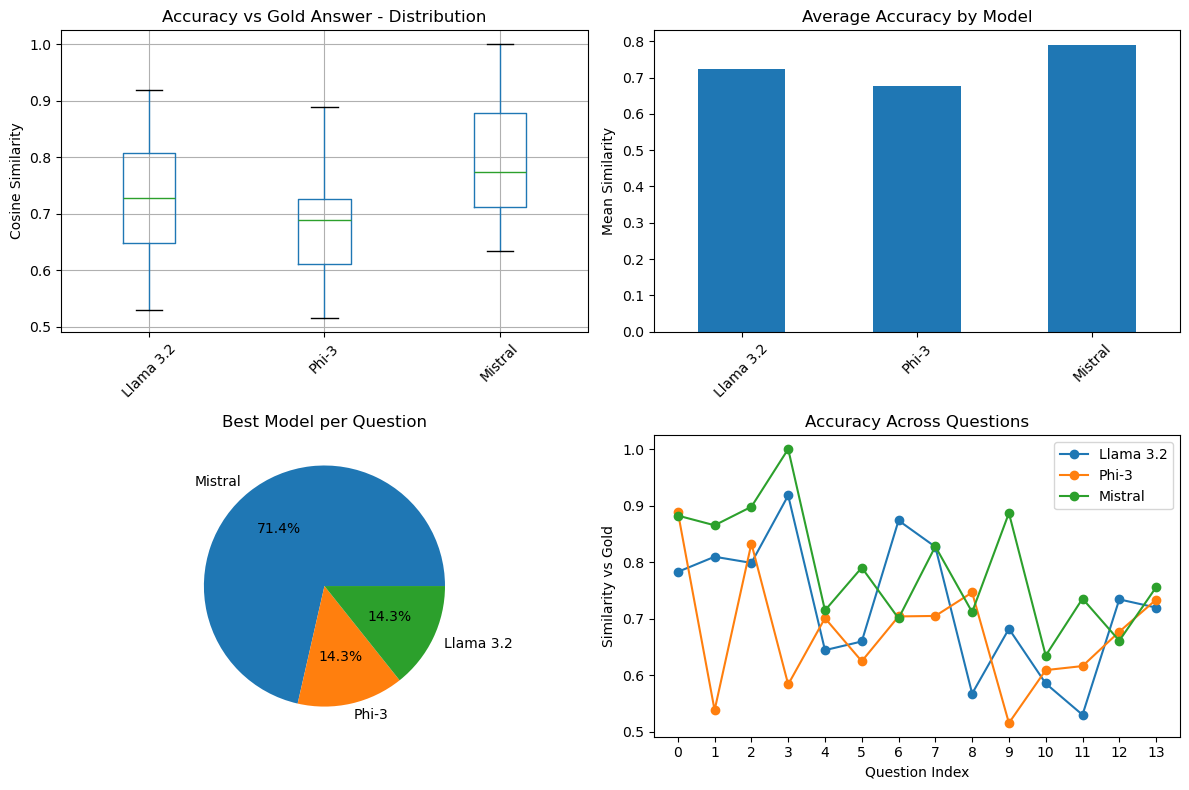

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))


# 1) Box plot of accuracy scores
plt.subplot(2, 2, 1)
df_acc[models].boxplot()
plt.title("Accuracy vs Gold Answer - Distribution")
plt.ylabel("Cosine Similarity")
plt.xticks(rotation=45)

# 2) Average accuracy per model
plt.subplot(2, 2, 2)
mean_scores.plot(kind="bar")
plt.title("Average Accuracy by Model")
plt.ylabel("Mean Similarity")
plt.xticks(rotation=45)

# 3) Best performing model per question (pie)
plt.subplot(2, 2, 3)
df_acc["Best_Model"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Best Model per Question")
plt.ylabel("")

# 4) Line plot across questions
plt.subplot(2, 2, 4)
for model in models:
    plt.plot(range(len(df_acc)), df_acc[model], marker="o", label=model)
plt.title("Accuracy Across Questions")
plt.xlabel("Question Index")
plt.ylabel("Similarity vs Gold")
plt.xticks(range(len(df_acc)))
plt.legend()

plt.tight_layout()
plt.show()


In [40]:
df_eval_full

,Question,Gold Answer,Llama Accuracy,Phi Accuracy,Mistral Accuracy,Llama Faithfulness,Phi Faithfulness,Mistral Faithfulness,Llama Detail,Phi Detail,Mistral Detail
0,What is a no-ball?,"A no-ball is an illegal delivery, usually for ...",0.782870,0.888924,0.882384,0.730091,0.800472,0.707447,50,104,67
1,What is a boundary six in cricket?,A boundary six is when the batter hits the bal...,0.809624,0.538370,0.865210,0.547975,0.450104,0.533895,51,24,52
2,What is the powerplay in ODI cricket?,The powerplay is a fielding restriction period...,0.798721,0.833021,0.897969,0.709125,0.755852,0.760073,27,65,47
3,What does LBW stand for?,LBW stands for Leg Before Wicket.,0.917916,0.583870,1.000000,0.542776,0.589315,0.498091,9,14,6
4,How many players constitute the playing eleven...,Each side’s playing eleven must consist of ele...,0.644462,0.701063,0.714787,0.504858,0.599114,0.605314,11,78,21
5,What is the maximum number of substitute field...,"In addition to the playing eleven, a team may ...",0.659846,0.624868,0.790409,0.752985,0.786080,0.774972,24,43,26
6,Can a player from the starting eleven be repla...,No — a member of the playing eleven may not be...,0.873702,0.704101,0.700635,0.744849,0.635206,0.701258,41,52,25
7,"If a substitute fielder is used, under what co...",Any substitute fielder must have been nominate...,0.827116,0.704976,0.827818,0.716870,0.716950,0.670748,87,31,30
8,"According to standard ODI playing conditions, ...",The ICC Match Referee or their nominee must ch...,0.567698,0.746485,0.711761,0.493663,0.693061,0.737810,7,19,32
9,Is the use of the standard Laws of Cricket ret...,Yes — except as varied by the ODI Playing Cond...,0.682240,0.515653,0.886899,0.462207,0.517304,0.587475,8,55,28


In [41]:
# (compared with the gold answer)
import pandas as pd

# Accuracy-only table per question
df_acc = pd.DataFrame({
    "Llama 3.2": df_eval_full["Llama Faithfulness"],
    "Phi-3": df_eval_full["Phi Faithfulness"],
    "Mistral": df_eval_full["Mistral Faithfulness"],
})

models = ["Llama 3.2", "Phi-3", "Mistral"]

mean_scores = df_acc.mean()

# Best model for each question (highest accuracy vs context)
df_acc["Best_Model"] = df_acc[models].idxmax(axis=1)

df_acc

,Llama 3.2,Phi-3,Mistral,Best_Model
0,0.730091,0.800472,0.707447,Phi-3
1,0.547975,0.450104,0.533895,Llama 3.2
2,0.709125,0.755852,0.760073,Mistral
3,0.542776,0.589315,0.498091,Phi-3
4,0.504858,0.599114,0.605314,Mistral
5,0.752985,0.786080,0.774972,Phi-3
6,0.744849,0.635206,0.701258,Llama 3.2
7,0.716870,0.716950,0.670748,Phi-3
8,0.493663,0.693061,0.737810,Mistral
9,0.462207,0.517304,0.587475,Mistral


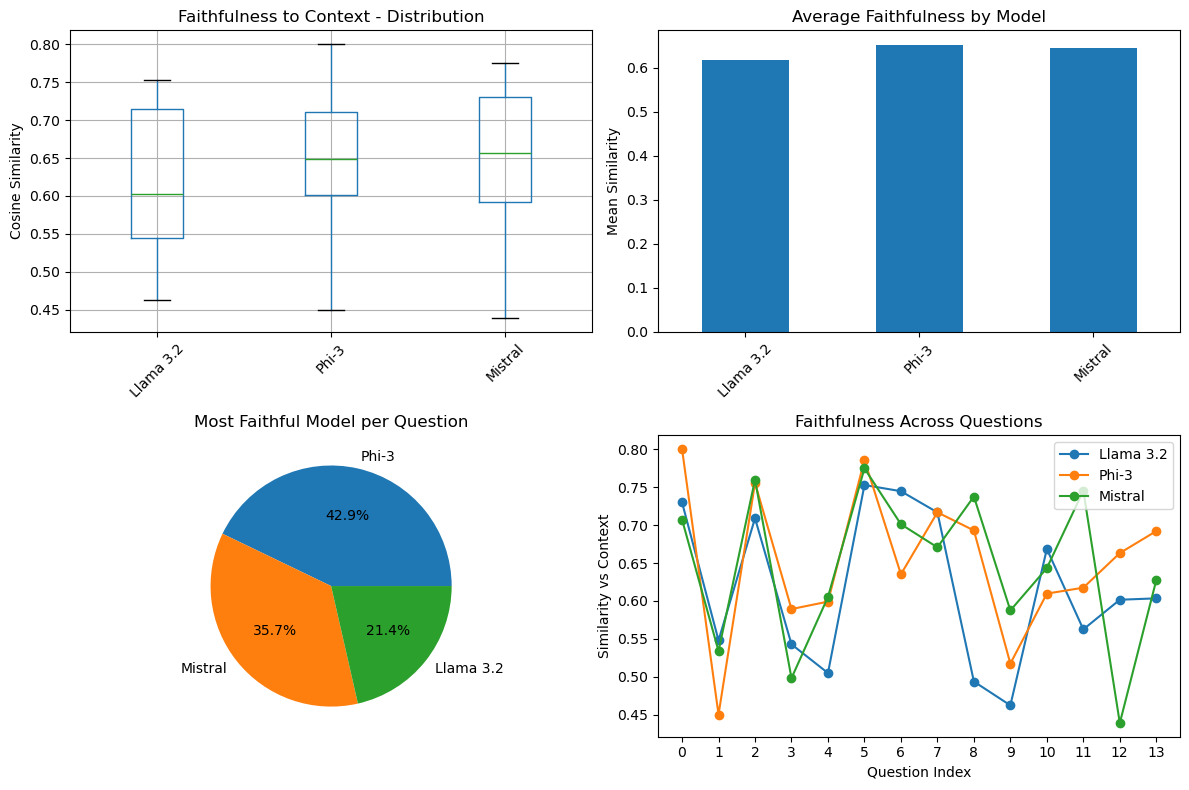

In [38]:
# Faithfulness-only table
df_faith = pd.DataFrame({
    "Llama 3.2": df_eval_full["Llama Faithfulness"],
    "Phi-3": df_eval_full["Phi Faithfulness"],
    "Mistral": df_eval_full["Mistral Faithfulness"],
})

models = ["Llama 3.2", "Phi-3", "Mistral"]
mean_faith = df_faith.mean()
df_faith["Best_Model"] = df_faith[models].idxmax(axis=1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
df_faith[models].boxplot()
plt.title("Faithfulness to Context - Distribution")
plt.ylabel("Cosine Similarity")
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
mean_faith.plot(kind="bar")
plt.title("Average Faithfulness by Model")
plt.ylabel("Mean Similarity")
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
df_faith["Best_Model"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Most Faithful Model per Question")
plt.ylabel("")

plt.subplot(2, 2, 4)
for model in models:
    plt.plot(range(len(df_faith)), df_faith[model], marker="o", label=model)
plt.title("Faithfulness Across Questions")
plt.xlabel("Question Index")
plt.ylabel("Similarity vs Context")
plt.xticks(range(len(df_faith)))
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
df_eval_full

In [ ]:
df_accuracy = pd.DataFrame({
    "Llama 3.2": df_eval_full["Llama Accuracy"],
    "Phi-3": df_eval_full["Phi Accuracy"],
    "Mistral": df_eval_full["Mistral Accuracy"],
})

cor_matrix_accuracy = df_accuracy.corr()


df_faith = pd.DataFrame({
    "Llama 3.2": df_eval_full["Llama Faithfulness"],
    "Phi-3": df_eval_full["Phi Faithfulness"],
    "Mistral": df_eval_full["Mistral Faithfulness"],
})

cor_matrix_faith = df_faith.corr()

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cor_matrix_accuracy, annot=True, cmap='coolwarm', square=True, fmt=".3f")
plt.title("Accuracy Correlation")

plt.subplot(1, 2, 2)
sns.heatmap(cor_matrix_faith, annot=True, cmap='coolwarm', square=True, fmt=".3f")
plt.title("Faithfulness Correlation")

plt.tight_layout()
plt.show()
